# Kalman Filter Tennis Ball Tracker

This notebook implements a Kalman-filter-style tracker for a small bright tennis ball in match video.

It assumes you already have a candidate extraction function, for example:

```python
candidates = extract_ball_candidates(...)
```

where `candidates` is a list of dictionaries or a pandas DataFrame containing at least `cx`, `cy`, and `score`.

The tracker is designed for the difficult case where each frame may contain multiple plausible candidates, most of which are noise. Instead of assuming one clean measurement with Gaussian uncertainty, the notebook treats candidate selection as a data-association problem.

The state is:

$\mathbf{x} = [x, y, v_x, v_y]^T$

Two prediction modes are included:

- `constant_velocity`: ordinary 2D constant-velocity motion.
- `image_parabola`: approximate projected parabolic motion in image space by adding a gravity-like vertical acceleration term and extra process noise.

The process noise includes a **maneuver noise** term that makes the tracker tolerant of sudden direction changes after racket hits and bounces.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Optional, Literal, Any

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x


In [2]:
@dataclass
class KalmanConfig:
    frame_width: int
    frame_height: int
    dt: float = 1.0

    prediction_mode: Literal["constant_velocity", "image_parabola"] = "constant_velocity"
    image_gravity_px_per_frame2: float = 0.15

    init_pos_std: float = 80.0
    init_vel_std: float = 30.0

    # High because candidate detections are noisy/discrete.
    measurement_std_px: float = 18.0

    process_pos_std: float = 3.0
    process_vel_std: float = 8.0

    # Extra uncertainty for racket hits, bounces, and sudden changes.
    maneuver_pos_std: float = 15.0
    maneuver_vel_std: float = 45.0

    gate_mahalanobis2: float = 16.0
    min_detection_score: float = 0.15
    max_candidates_per_frame: int = 50

    detector_score_weight: float = 1.0
    distance_score_weight: float = 1.5
    center_bias_weight: float = 0.15
    velocity_consistency_weight: float = 0.35
    center_bias_sigma_frac: float = 0.55

    max_missed_frames: int = 12
    min_confirmed_hits: int = 3

    allow_reinitialize: bool = True
    reinit_min_candidate_score: float = 0.65

    keep_debug_info: bool = True


## 2. Candidate normalization helpers

In [3]:
def candidates_to_dataframe(candidates: Any) -> pd.DataFrame:
    """Normalize candidate output into a DataFrame with cx, cy, score columns."""
    if candidates is None:
        return pd.DataFrame(columns=["cx", "cy", "score"])

    if isinstance(candidates, pd.DataFrame):
        df = candidates.copy()
    else:
        df = pd.DataFrame(candidates)

    if len(df) == 0:
        return pd.DataFrame(columns=["cx", "cy", "score"])

    required = {"cx", "cy", "score"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Candidates are missing required columns: {missing}")

    df = df.copy()
    df["cx"] = pd.to_numeric(df["cx"], errors="coerce")
    df["cy"] = pd.to_numeric(df["cy"], errors="coerce")
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    df = df.dropna(subset=["cx", "cy", "score"])
    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    return df


def candidate_positions(df: pd.DataFrame) -> np.ndarray:
    if len(df) == 0:
        return np.empty((0, 2), dtype=float)
    return df[["cx", "cy"]].to_numpy(dtype=float)


## 3. Kalman filter math functions

In [4]:
def state_transition_matrix(dt: float) -> np.ndarray:
    return np.array([
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ], dtype=float)


def measurement_matrix() -> np.ndarray:
    return np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
    ], dtype=float)


def process_noise_matrix(cfg: KalmanConfig, maneuver: bool = False) -> np.ndarray:
    pos_std = cfg.process_pos_std
    vel_std = cfg.process_vel_std

    if maneuver:
        pos_std = np.sqrt(pos_std**2 + cfg.maneuver_pos_std**2)
        vel_std = np.sqrt(vel_std**2 + cfg.maneuver_vel_std**2)

    return np.diag([pos_std**2, pos_std**2, vel_std**2, vel_std**2]).astype(float)


def measurement_noise_matrix(cfg: KalmanConfig) -> np.ndarray:
    s2 = cfg.measurement_std_px ** 2
    return np.diag([s2, s2]).astype(float)


def predict_state(x: np.ndarray, P: np.ndarray, cfg: KalmanConfig, maneuver: bool = False) -> tuple[np.ndarray, np.ndarray]:
    F = state_transition_matrix(cfg.dt)
    Q = process_noise_matrix(cfg, maneuver=maneuver)
    x_pred = F @ x

    if cfg.prediction_mode == "image_parabola":
        g = cfg.image_gravity_px_per_frame2
        dt = cfg.dt
        x_pred[1] += 0.5 * g * dt**2
        x_pred[3] += g * dt

    P_pred = F @ P @ F.T + Q
    return x_pred, P_pred


def kalman_update(x_pred: np.ndarray, P_pred: np.ndarray, z: np.ndarray, cfg: KalmanConfig) -> tuple[np.ndarray, np.ndarray, dict]:
    H = measurement_matrix()
    R = measurement_noise_matrix(cfg)
    innovation = z - H @ x_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    x_new = x_pred + K @ innovation
    I = np.eye(len(x_pred))
    P_new = (I - K @ H) @ P_pred
    debug = {"innovation": innovation, "innovation_norm": float(np.linalg.norm(innovation)), "kalman_gain": K}
    return x_new, P_new, debug


## 4. Candidate scoring and measurement selection

This is the key adaptation for your problem. The detector returns many possible positions, not one clean Gaussian measurement. So we score each candidate against the predicted track and either accept the best candidate or declare a missed detection.

In [5]:
def mahalanobis_distance2(z: np.ndarray, x_pred: np.ndarray, P_pred: np.ndarray, cfg: KalmanConfig) -> float:
    H = measurement_matrix()
    R = measurement_noise_matrix(cfg)
    residual = z - H @ x_pred
    S = H @ P_pred @ H.T + R
    return float(residual.T @ np.linalg.inv(S) @ residual)


def center_bias_score(z: np.ndarray, cfg: KalmanConfig) -> float:
    center = np.array([cfg.frame_width / 2, cfg.frame_height / 2], dtype=float)
    diag = np.sqrt(cfg.frame_width**2 + cfg.frame_height**2)
    sigma = cfg.center_bias_sigma_frac * diag
    d2 = float(np.sum((z - center) ** 2))
    return float(np.exp(-0.5 * d2 / (sigma**2)))


def distance_likelihood_score(d2_mahal: float) -> float:
    return float(np.exp(-0.5 * d2_mahal))


def velocity_consistency_score(z: np.ndarray, prev_x: Optional[np.ndarray], cfg: KalmanConfig) -> float:
    if prev_x is None:
        return 1.0
    prev_pos = prev_x[:2]
    prev_vel = prev_x[2:]
    expected = prev_pos + prev_vel * cfg.dt
    err = np.linalg.norm(z - expected)
    sigma = max(cfg.measurement_std_px * 3.0, 1.0)
    return float(np.exp(-0.5 * (err / sigma) ** 2))


def normalize_detector_scores(scores: np.ndarray) -> np.ndarray:
    scores = np.asarray(scores, dtype=float)
    if len(scores) == 0:
        return scores
    if np.nanmin(scores) >= 0 and np.nanmax(scores) <= 1:
        return np.nan_to_num(scores, nan=0.0, posinf=1.0, neginf=0.0)
    lo, hi = np.nanpercentile(scores, [5, 95])
    if hi <= lo:
        return np.ones_like(scores) * 0.5
    return np.clip((scores - lo) / (hi - lo), 0, 1)


def score_candidates(candidates: pd.DataFrame, x_pred: np.ndarray, P_pred: np.ndarray, cfg: KalmanConfig, prev_x: Optional[np.ndarray] = None) -> pd.DataFrame:
    df = candidates_to_dataframe(candidates).head(cfg.max_candidates_per_frame).copy()
    if len(df) == 0:
        return df

    detector_scores = normalize_detector_scores(df["score"].to_numpy(dtype=float))
    rows = []
    for i, row in df.iterrows():
        z = np.array([row["cx"], row["cy"]], dtype=float)
        d2 = mahalanobis_distance2(z, x_pred, P_pred, cfg)
        det_s = float(detector_scores[i])
        dist_s = distance_likelihood_score(d2)
        center_s = center_bias_score(z, cfg)
        vel_s = velocity_consistency_score(z, prev_x, cfg)

        eps = 1e-9
        weights = np.array([cfg.detector_score_weight, cfg.distance_score_weight, cfg.center_bias_weight, cfg.velocity_consistency_weight])
        vals = np.array([det_s, dist_s, center_s, vel_s])
        combined = float(np.exp(np.sum(weights * np.log(vals + eps)) / np.sum(weights)))

        rows.append({
            "candidate_index": i,
            "mahalanobis2": d2,
            "detector_score_norm": det_s,
            "distance_score": dist_s,
            "center_score": center_s,
            "velocity_score": vel_s,
            "combined_score": combined,
        })

    scored = pd.concat([df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
    return scored.sort_values("combined_score", ascending=False).reset_index(drop=True)


def choose_measurement(scored_candidates: pd.DataFrame, cfg: KalmanConfig) -> tuple[Optional[np.ndarray], Optional[pd.Series], str]:
    if len(scored_candidates) == 0:
        return None, None, "no_candidates"
    best = scored_candidates.iloc[0]
    if best["mahalanobis2"] > cfg.gate_mahalanobis2:
        return None, best, "outside_gate"
    if best["combined_score"] < cfg.min_detection_score:
        return None, best, "below_score_threshold"
    z = np.array([best["cx"], best["cy"]], dtype=float)
    return z, best, "accepted"


## 5. Track state object and initialization

In [6]:
@dataclass
class TrackState:
    x: Optional[np.ndarray] = None
    P: Optional[np.ndarray] = None
    active: bool = False
    hits: int = 0
    misses: int = 0
    age: int = 0
    last_frame_idx: Optional[int] = None
    history: list[dict] = field(default_factory=list)


def initialize_track_from_candidate(candidate: pd.Series, cfg: KalmanConfig, frame_idx: int) -> TrackState:
    x0 = np.array([candidate["cx"], candidate["cy"], 0.0, 0.0], dtype=float)
    P0 = np.diag([cfg.init_pos_std**2, cfg.init_pos_std**2, cfg.init_vel_std**2, cfg.init_vel_std**2]).astype(float)
    return TrackState(x=x0, P=P0, active=True, hits=1, misses=0, age=1, last_frame_idx=frame_idx, history=[])


def maybe_initialize_track(candidates: pd.DataFrame, cfg: KalmanConfig, frame_idx: int) -> Optional[TrackState]:
    df = candidates_to_dataframe(candidates)
    if len(df) == 0:
        return None
    normalized = normalize_detector_scores(df["score"].to_numpy(dtype=float))
    best = df.iloc[0].copy()
    if float(normalized[0]) < cfg.reinit_min_candidate_score:
        return None
    best["detector_score_norm"] = float(normalized[0])
    return initialize_track_from_candidate(best, cfg, frame_idx)


## 6. Single-frame tracker step

In [7]:
def kalman_tracker_step(track: Optional[TrackState], candidates: pd.DataFrame, cfg: KalmanConfig, frame_idx: int) -> TrackState:
    candidates = candidates_to_dataframe(candidates)

    if track is None or not track.active or track.x is None or track.P is None:
        new_track = maybe_initialize_track(candidates, cfg, frame_idx)
        if new_track is None:
            new_track = TrackState(active=False)
            new_track.history.append({"frame_idx": frame_idx, "status": "inactive_no_initialization", "accepted": False, "x": np.nan, "y": np.nan, "vx": np.nan, "vy": np.nan})
        return new_track

    previous_x = track.x.copy()
    maneuver = track.misses > 0
    x_pred, P_pred = predict_state(track.x, track.P, cfg, maneuver=maneuver)
    scored = score_candidates(candidates, x_pred, P_pred, cfg, prev_x=previous_x)
    z, best, reason = choose_measurement(scored, cfg)

    accepted = z is not None
    debug = {}
    if accepted:
        track.x, track.P, debug = kalman_update(x_pred, P_pred, z, cfg)
        track.hits += 1
        track.misses = 0
        status = "updated"
    else:
        track.x, track.P = x_pred, P_pred
        track.misses += 1
        status = f"missed_{reason}"

    track.age += 1
    track.last_frame_idx = frame_idx

    if track.misses > cfg.max_missed_frames:
        track.active = False
        status = "deactivated_too_many_misses"

    record = {
        "frame_idx": frame_idx,
        "status": status,
        "accepted": accepted,
        "x": float(track.x[0]),
        "y": float(track.x[1]),
        "vx": float(track.x[2]),
        "vy": float(track.x[3]),
        "hits": track.hits,
        "misses": track.misses,
        "age": track.age,
        "confirmed": track.hits >= cfg.min_confirmed_hits,
        "best_cx": float(best["cx"]) if best is not None else np.nan,
        "best_cy": float(best["cy"]) if best is not None else np.nan,
        "best_combined_score": float(best["combined_score"]) if best is not None and "combined_score" in best else np.nan,
        "best_detector_score": float(best["score"]) if best is not None and "score" in best else np.nan,
        "best_mahalanobis2": float(best["mahalanobis2"]) if best is not None and "mahalanobis2" in best else np.nan,
        "reason": reason,
    }
    if cfg.keep_debug_info:
        record["debug"] = debug
        record["num_candidates"] = len(candidates)
    track.history.append(record)
    return track


## 7. Candidate extraction copied from your parameter-tuner notebook

This cell is copied directly from your uploaded `ball_detection_parameter_tuner` notebook. It includes `extract_ball_candidates` and the helper functions it depends on, so the tracker can call it without you manually copying helpers.

The tracker wrapper below can use either:
- positive frame-to-frame differences computed from the raw match video, or
- an already-created adjacent-frame-difference video.


In [24]:

def get_video_info(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return {
        "width": width,
        "height": height,
        "fps": fps,
        "frame_count": frame_count,
    }

def read_video_frame(video_path, frame_idx):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok or frame is None:
        raise ValueError(f"Could not read frame {frame_idx} from {video_path}")
    return frame

def to_gray(frame):
    if frame.ndim == 2:
        return frame
    return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

def maybe_blur(gray, ksize):
    if ksize is None or int(ksize) <= 1:
        return gray
    ksize = int(ksize)
    if ksize % 2 == 0:
        ksize += 1
    return cv2.GaussianBlur(gray, (ksize, ksize), 0)

def threshold_motion(gray, diff_thresh):
    _, binary = cv2.threshold(gray, int(diff_thresh), 255, cv2.THRESH_BINARY)
    return binary

def make_allowed_mask(shape_hw, mode="none", rect=None, polygon_points=None):
    h, w = shape_hw
    mask = np.zeros((h, w), dtype=np.uint8)

    if mode == "none":
        mask[:, :] = 255
        return mask

    if mode == "rectangle":
        if rect is None:
            raise ValueError("rect must be provided for rectangle mode")
        x0, y0, x1, y1 = rect
        x0, x1 = sorted([int(x0), int(x1)])
        y0, y1 = sorted([int(y0), int(y1)])
        x0 = max(0, min(w - 1, x0))
        x1 = max(0, min(w, x1))
        y0 = max(0, min(h - 1, y0))
        y1 = max(0, min(h, y1))
        mask[y0:y1, x0:x1] = 255
        return mask

    if mode == "polygon":
        if polygon_points is None or len(polygon_points) < 3:
            raise ValueError("polygon_points must contain at least 3 points")
        pts = np.array(polygon_points, dtype=np.int32)
        cv2.fillPoly(mask, [pts], 255)
        return mask

    raise ValueError(f"Unknown mode: {mode}")

def circularity_from_stats(area, perimeter):
    if perimeter <= 0:
        return 0.0
    return float(4.0 * np.pi * area / (perimeter ** 2))

def extract_ball_candidates(
    diff_gray,
    ball_diameter_px,
    diff_thresh=22,
    min_area_scale=0.20,
    max_area_scale=2.50,
    min_bbox_scale=0.50,
    max_bbox_scale=1.80,
    min_circularity=0.35,
    min_mean_intensity=15.0,
    max_aspect_ratio=2.20,
    top_k=5,
    allowed_mask=None,
    gaussian_blur_ksize=3,
):
    diff_gray = to_gray(diff_gray)
    proc_gray = maybe_blur(diff_gray, gaussian_blur_ksize)
    binary = threshold_motion(proc_gray, diff_thresh)

    if allowed_mask is not None:
        binary = cv2.bitwise_and(binary, allowed_mask)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    expected_area = np.pi * (ball_diameter_px / 2.0) ** 2
    min_area = min_area_scale * expected_area
    max_area = max_area_scale * expected_area
    min_bbox = min_bbox_scale * ball_diameter_px
    max_bbox = max_bbox_scale * ball_diameter_px

    candidates = []

    for label_id in range(1, num_labels):
        x = stats[label_id, cv2.CC_STAT_LEFT]
        y = stats[label_id, cv2.CC_STAT_TOP]
        w = stats[label_id, cv2.CC_STAT_WIDTH]
        h = stats[label_id, cv2.CC_STAT_HEIGHT]
        area = float(stats[label_id, cv2.CC_STAT_AREA])

        if area < min_area or area > max_area:
            continue
        if w < min_bbox or h < min_bbox:
            continue
        if w > max_bbox or h > max_bbox:
            continue

        aspect_ratio = max(w / max(h, 1), h / max(w, 1))
        if aspect_ratio > max_aspect_ratio:
            continue

        component_mask = (labels == label_id).astype(np.uint8) * 255
        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        cnt = max(contours, key=cv2.contourArea)
        perimeter = float(cv2.arcLength(cnt, closed=True))
        circularity = circularity_from_stats(area, perimeter)
        if circularity < min_circularity:
            continue

        mean_intensity = float(cv2.mean(diff_gray, mask=component_mask)[0])
        if mean_intensity < min_mean_intensity:
            continue

        cx, cy = centroids[label_id]
        radius_est = 0.25 * (w + h)

        area_ratio = area / max(expected_area, 1e-6)
        area_score = 1.0 / (1.0 + abs(np.log(max(area_ratio, 1e-6))))
        circle_score = circularity
        intensity_score = mean_intensity / 255.0
        aspect_score = 1.0 / max(aspect_ratio, 1.0)

        frame_h, frame_w = diff_gray.shape[:2]
        frame_cx = frame_w / 2.0
        frame_cy = frame_h / 2.0

        # Candidate center distance
        dx_center = cx - frame_cx
        dy_center = cy - frame_cy
        dist_center = np.sqrt(dx_center**2 + dy_center**2)

        # Normalize (so it's between ~0 and 1)
        max_dist = np.sqrt(frame_cx**2 + frame_cy**2)
        center_penalty = dist_center / max_dist

        score = (
            0 * area_score
            + 0.30 * circle_score
            + 0.45 * intensity_score
            + 0.10 * aspect_score
            - 0.15 * center_penalty
        )

        candidates.append({
            "label_id": int(label_id),
            "x": int(x),
            "y": int(y),
            "w": int(w),
            "h": int(h),
            "cx": float(cx),
            "cy": float(cy),
            "area": float(area),
            "mean_intensity": float(mean_intensity),
            "circularity": float(circularity),
            "aspect_ratio": float(aspect_ratio),
            "radius_est": float(radius_est),
            "score": float(score),
        })

    candidates = sorted(candidates, key=lambda c: c["score"], reverse=True)
    return candidates[:top_k], {
        "diff_gray": diff_gray,
        "proc_gray": proc_gray,
        "binary": binary,
        "labels": labels,
        "stats": stats,
        "centroids": centroids,
        "expected_area": expected_area,
        "num_labels": num_labels,
    }

def draw_candidates_on_frame(gray_frame, candidates, allowed_mask=None, show_labels=True):
    if gray_frame.ndim == 2:
        overlay = cv2.cvtColor(gray_frame, cv2.COLOR_GRAY2BGR)
    else:
        overlay = gray_frame.copy()

    if allowed_mask is not None:
        boundary = cv2.Canny(allowed_mask, 50, 150)
        overlay[boundary > 0] = (255, 255, 0)

    for i, c in enumerate(candidates):
        cx, cy = int(round(c["cx"])), int(round(c["cy"]))
        r = max(2, int(round(c["radius_est"])))
        cv2.circle(overlay, (cx, cy), r, (0, 255, 0), 2)
        cv2.rectangle(overlay, (c["x"], c["y"]), (c["x"] + c["w"], c["y"] + c["h"]), (0, 128, 255), 1)
        if show_labels:
            txt = f"{i+1}: {c['score']:.2f}"
            cv2.putText(overlay, txt, (cx + 4, cy - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 255), 1, cv2.LINE_AA)
    return overlay

def parse_polygon_text(text):
    lines = [ln.strip() for ln in text.strip().splitlines() if ln.strip()]
    pts = []
    for ln in lines:
        parts = ln.replace(",", " ").split()
        if len(parts) != 2:
            continue
        x, y = float(parts[0]), float(parts[1])
        pts.append((int(round(x)), int(round(y))))
    return pts

def preview_detection(
    video_path,
    frame_idx,
    ball_diameter_px,
    diff_thresh,
    min_area_scale,
    max_area_scale,
    min_bbox_scale,
    max_bbox_scale,
    min_circularity,
    min_mean_intensity,
    max_aspect_ratio,
    top_k,
    gaussian_blur_ksize,
    region_mode,
    rect_x0,
    rect_y0,
    rect_x1,
    rect_y1,
    polygon_text,
    show_binary=True,
    show_processed=False,
):
    frame = read_video_frame(video_path, frame_idx)
    gray = to_gray(frame)

    allowed_mask = None
    polygon_points = None
    if region_mode == "rectangle":
        allowed_mask = make_allowed_mask(
            gray.shape,
            mode="rectangle",
            rect=(rect_x0, rect_y0, rect_x1, rect_y1),
        )
    elif region_mode == "polygon":
        polygon_points = parse_polygon_text(polygon_text)
        allowed_mask = make_allowed_mask(
            gray.shape,
            mode="polygon",
            polygon_points=polygon_points,
        )

    candidates, debug = extract_ball_candidates(
        diff_gray=gray,
        ball_diameter_px=ball_diameter_px,
        diff_thresh=diff_thresh,
        min_area_scale=min_area_scale,
        max_area_scale=max_area_scale,
        min_bbox_scale=min_bbox_scale,
        max_bbox_scale=max_bbox_scale,
        min_circularity=min_circularity,
        min_mean_intensity=min_mean_intensity,
        max_aspect_ratio=max_aspect_ratio,
        top_k=top_k,
        allowed_mask=allowed_mask,
        gaussian_blur_ksize=gaussian_blur_ksize,
    )

    overlay = draw_candidates_on_frame(gray, candidates, allowed_mask=allowed_mask, show_labels=True)

    cols = 3 if (show_binary or show_processed) else 1
    fig, axes = plt.subplots(1, cols, figsize=(6 * cols, 6))

    if cols == 1:
        axes = [axes]

    ax0 = axes[0]
    ax0.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax0.set_title(f"Overlay on frame {frame_idx}")
    ax0.axis("off")

    next_ax = 1
    if show_binary:
        axes[next_ax].imshow(debug["binary"], cmap="gray", vmin=0, vmax=255)
        axes[next_ax].set_title("Thresholded / filtered mask")
        axes[next_ax].axis("off")
        next_ax += 1

    if show_processed:
        axes[next_ax].imshow(debug["proc_gray"], cmap="gray", vmin=0, vmax=255)
        axes[next_ax].set_title("Processed grayscale")
        axes[next_ax].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Frame: {frame_idx}")
    print(f"Candidates returned: {len(candidates)}")
    print(f"Expected ball area: {debug['expected_area']:.2f} px^2")
    print()

    if len(candidates) == 0:
        print("No candidates found with current parameters.")
    else:
        for i, c in enumerate(candidates, start=1):
            print(
                f"{i}. center=({c['cx']:.1f}, {c['cy']:.1f}) "
                f"bbox=({c['w']}x{c['h']}) area={c['area']:.1f} "
                f"circ={c['circularity']:.3f} mean={c['mean_intensity']:.1f} "
                f"aspect={c['aspect_ratio']:.2f} score={c['score']:.3f}"
            )

    return candidates, debug, overlay


## 8. Tracker wrapper around copied candidate extractor

In [25]:
def build_allowed_mask_from_kwargs(frame_shape_hw: tuple[int, int], candidate_kwargs: Optional[dict] = None) -> Optional[np.ndarray]:
    """Build an optional allowed-region mask from candidate_kwargs.

    Supported options:
      - allowed_mask: pass a ready-made uint8 mask directly
      - region_mode="none" | "rectangle" | "polygon"
      - rect=(x0, y0, x1, y1)
      - polygon_points=[(x, y), ...]
    """
    candidate_kwargs = candidate_kwargs or {}

    if candidate_kwargs.get("allowed_mask", None) is not None:
        return candidate_kwargs["allowed_mask"]

    region_mode = candidate_kwargs.get("region_mode", "none")
    if region_mode == "none" or region_mode is None:
        return None

    if region_mode == "rectangle":
        return make_allowed_mask(
            frame_shape_hw,
            mode="rectangle",
            rect=candidate_kwargs.get("rect", None),
        )

    if region_mode == "polygon":
        return make_allowed_mask(
            frame_shape_hw,
            mode="polygon",
            polygon_points=candidate_kwargs.get("polygon_points", None),
        )

    raise ValueError(f"Unknown region_mode: {region_mode}")


def positive_frame_difference(curr_frame_bgr: np.ndarray, prev_frame_bgr: np.ndarray) -> np.ndarray:
    """Keep only pixels that got brighter from prev -> curr.

    This is different from cv2.absdiff: negative changes become 0.
    """
    curr_gray = to_gray(curr_frame_bgr)
    prev_gray = to_gray(prev_frame_bgr)
    return cv2.subtract(curr_gray, prev_gray)


def get_candidates_for_frame(
    frame_bgr: np.ndarray,
    prev_frame_bgr: Optional[np.ndarray],
    frame_idx: int,
    candidate_kwargs: Optional[dict] = None,
) -> pd.DataFrame:
    """Run your copied extract_ball_candidates function for one tracker frame.

    candidate_kwargs controls the detector parameters. Important options:

      source_mode:
        "positive_frame_difference"  -> compute cv2.subtract(curr_gray, prev_gray)
        "absolute_frame_difference"  -> compute cv2.absdiff(curr_gray, prev_gray)
        "precomputed_diff_video"     -> read this frame from diff_video_path

      diff_video_path:
        path to an adjacent-frame-difference video, only used when
        source_mode="precomputed_diff_video"

    Returns a DataFrame with at least cx, cy, score, plus the shape/brightness columns.
    """
    candidate_kwargs = candidate_kwargs or {}
    source_mode = candidate_kwargs.get("source_mode", "positive_frame_difference")

    if source_mode == "precomputed_diff_video":
        diff_video_path = candidate_kwargs.get("diff_video_path", None)
        if not diff_video_path:
            raise ValueError('candidate_kwargs["diff_video_path"] is required for source_mode="precomputed_diff_video"')
        diff_frame = read_video_frame(diff_video_path, frame_idx)
        diff_gray = to_gray(diff_frame)

    else:
        if prev_frame_bgr is None:
            return pd.DataFrame(columns=["cx", "cy", "score"])

        if source_mode == "positive_frame_difference":
            diff_gray = positive_frame_difference(frame_bgr, prev_frame_bgr)
        elif source_mode == "absolute_frame_difference":
            diff_gray = cv2.absdiff(to_gray(frame_bgr), to_gray(prev_frame_bgr))
        else:
            raise ValueError(f"Unknown source_mode: {source_mode}")

    allowed_mask = build_allowed_mask_from_kwargs(diff_gray.shape, candidate_kwargs)

    candidates, debug = extract_ball_candidates(
        diff_gray=diff_gray,
        ball_diameter_px=candidate_kwargs.get("ball_diameter_px", 8),
        diff_thresh=candidate_kwargs.get("diff_thresh", 18),
        min_area_scale=candidate_kwargs.get("min_area_scale", 0.20),
        max_area_scale=candidate_kwargs.get("max_area_scale", 2.50),
        min_bbox_scale=candidate_kwargs.get("min_bbox_scale", 0.50),
        max_bbox_scale=candidate_kwargs.get("max_bbox_scale", 1.80),
        min_circularity=candidate_kwargs.get("min_circularity", 0.35),
        min_mean_intensity=candidate_kwargs.get("min_mean_intensity", 15.0),
        max_aspect_ratio=candidate_kwargs.get("max_aspect_ratio", 2.20),
        top_k=candidate_kwargs.get("top_k", 40),
        allowed_mask=allowed_mask,
        gaussian_blur_ksize=candidate_kwargs.get("gaussian_blur_ksize", 3),
    )

    df = candidates_to_dataframe(candidates)

    # Preserve useful debugging info without forcing the tracker to use it.
    # You can inspect these globals after running a frame if desired.
    global last_candidate_debug
    last_candidate_debug = debug

    return df


## 9. Run tracker over a video

In [26]:
def run_tracker_on_video(video_path: str, cfg: KalmanConfig, start_frame: int = 0, num_frames: Optional[int] = None, candidate_kwargs: Optional[dict] = None, resize: Optional[tuple[int, int]] = None) -> pd.DataFrame:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    end_frame = total_frames if num_frames is None else min(total_frames, start_frame + num_frames)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    track: Optional[TrackState] = None
    prev_frame = None
    all_records = []

    for frame_idx in tqdm(range(start_frame, end_frame), desc="Tracking"):
        ret, frame = cap.read()
        if not ret:
            break
        if resize is not None:
            frame = cv2.resize(frame, resize)

        candidates = get_candidates_for_frame(frame, prev_frame, frame_idx, candidate_kwargs)
        track = kalman_tracker_step(track, candidates, cfg, frame_idx)

        if track is not None and not track.active and cfg.allow_reinitialize:
            reinit = maybe_initialize_track(candidates, cfg, frame_idx)
            if reinit is not None:
                track = reinit
                track.history.append({"frame_idx": frame_idx, "status": "reinitialized", "accepted": True, "x": float(track.x[0]), "y": float(track.x[1]), "vx": float(track.x[2]), "vy": float(track.x[3]), "hits": track.hits, "misses": track.misses, "age": track.age, "confirmed": False})

        if track is not None and len(track.history) > 0:
            all_records.append(track.history[-1])
        prev_frame = frame.copy()

    cap.release()
    return pd.DataFrame(all_records)


## 10. Visualization helpers

In [27]:
def plot_track_history(history: pd.DataFrame, frame_width: int, frame_height: int, only_confirmed: bool = False):
    if len(history) == 0:
        print("No history to plot.")
        return
    df = history.copy()
    if only_confirmed and "confirmed" in df.columns:
        df = df[df["confirmed"]]
    plt.figure(figsize=(10, 6))
    plt.plot(df["x"], df["y"], marker="o", markersize=2, linewidth=1, label="Kalman track")
    if "accepted" in df.columns:
        accepted = df[df["accepted"]]
        missed = df[~df["accepted"]]
        plt.scatter(accepted["x"], accepted["y"], s=16, label="Accepted measurement")
        plt.scatter(missed["x"], missed["y"], s=10, marker="x", label="Prediction only / missed")
    plt.xlim(0, frame_width)
    plt.ylim(frame_height, 0)
    plt.xlabel("x [px]")
    plt.ylabel("y [px]")
    plt.title("Tracked ball path")
    plt.legend()
    plt.grid(True)
    plt.show()


def overlay_track_on_frame(frame_bgr: np.ndarray, row: pd.Series, radius: int = 8) -> np.ndarray:
    out = frame_bgr.copy()
    if not np.isfinite(row.get("x", np.nan)) or not np.isfinite(row.get("y", np.nan)):
        return out
    x, y = int(round(row["x"])), int(round(row["y"]))
    accepted = bool(row.get("accepted", False))
    color = (0, 255, 0) if accepted else (0, 165, 255)
    cv2.circle(out, (x, y), radius, color, 2)
    cv2.putText(out, str(row.get("status", "")), (x + 10, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    return out


def show_debug_frame(video_path: str, history: pd.DataFrame, frame_idx: int, resize: Optional[tuple[int, int]] = None):
    row_df = history[history["frame_idx"] == frame_idx]
    if len(row_df) == 0:
        raise ValueError(f"No tracker history for frame {frame_idx}")
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not read frame {frame_idx}")
    if resize is not None:
        frame = cv2.resize(frame, resize)
    out = overlay_track_on_frame(frame, row_df.iloc[0])
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Frame {frame_idx}")
    plt.show()


## 11. Save tracked trajectory video and CSV

This makes an annotated output video and saves the tracker table. Green circles are accepted detections; orange circles are prediction-only frames; faint trail points show the recent estimated path. Frames without a good detection remain labeled in the CSV through the `accepted` and `status` columns.


In [28]:
def save_tracking_outputs(
    video_path: str,
    history: pd.DataFrame,
    output_video_path: str = "kalman_ball_tracking_overlay.mp4",
    output_csv_path: str = "kalman_ball_tracking_history.csv",
    resize: Optional[tuple[int, int]] = None,
    trail_length: int = 25,
    radius: int = 8,
    draw_only_confirmed: bool = False,
) -> tuple[str, str]:
    """Save an annotated video and the frame-by-frame tracking table.

    The CSV is the main data product:
      accepted=True  -> a candidate was good enough and used as a measurement
      accepted=False -> no candidate was good enough; the row is prediction-only
      status         -> explains update/miss/deactivation/reinitialization
    """
    if history is None or len(history) == 0:
        raise ValueError("history is empty. Run run_tracker_on_video first.")

    history_to_save = history.copy()
    if "debug" in history_to_save.columns:
        history_to_save = history_to_save.drop(columns=["debug"])
    history_to_save.to_csv(output_csv_path, index=False)

    hist_by_frame = {int(r["frame_idx"]): r for _, r in history.iterrows()}

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    fps = float(cap.get(cv2.CAP_PROP_FPS))
    if not np.isfinite(fps) or fps <= 0:
        fps = 30.0

    first_frame_idx = int(history["frame_idx"].min())
    last_frame_idx = int(history["frame_idx"].max())

    cap.set(cv2.CAP_PROP_POS_FRAMES, first_frame_idx)
    ok, first = cap.read()
    if not ok:
        cap.release()
        raise ValueError(f"Could not read first frame {first_frame_idx}")
    if resize is not None:
        first = cv2.resize(first, resize)

    h, w = first.shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

    recent_points: list[tuple[int, int, bool]] = []

    def draw_row(frame: np.ndarray, row: pd.Series) -> np.ndarray:
        out = frame.copy()

        is_confirmed = bool(row.get("confirmed", False))
        if draw_only_confirmed and not is_confirmed:
            return out

        x_val = row.get("x", np.nan)
        y_val = row.get("y", np.nan)
        if not np.isfinite(x_val) or not np.isfinite(y_val):
            return out

        x, y = int(round(x_val)), int(round(y_val))
        accepted = bool(row.get("accepted", False))
        color = (0, 255, 0) if accepted else (0, 165, 255)

        recent_points.append((x, y, accepted))
        if len(recent_points) > trail_length:
            del recent_points[:-trail_length]

        for tx, ty, tacc in recent_points:
            tcolor = (0, 180, 0) if tacc else (0, 120, 255)
            cv2.circle(out, (tx, ty), 2, tcolor, -1)

        cv2.circle(out, (x, y), radius, color, 2)
        cv2.drawMarker(out, (x, y), color, markerType=cv2.MARKER_CROSS, markerSize=12, thickness=1)

        label = f"{int(row['frame_idx'])}: {row.get('status', '')}"
        cv2.putText(out, label, (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.75, color, 2, cv2.LINE_AA)

        if np.isfinite(row.get("best_combined_score", np.nan)):
            score_text = f"combined={row['best_combined_score']:.3f}, detector={row.get('best_detector_score', np.nan):.3f}"
            cv2.putText(out, score_text, (10, 56), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 1, cv2.LINE_AA)

        return out

    # Write the first frame, then continue.
    frame_idx = first_frame_idx
    frame = first
    while frame_idx <= last_frame_idx:
        row = hist_by_frame.get(frame_idx, None)
        out = frame if row is None else draw_row(frame, pd.Series(row))
        writer.write(out)

        frame_idx += 1
        if frame_idx > last_frame_idx:
            break

        ok, frame = cap.read()
        if not ok:
            break
        if resize is not None:
            frame = cv2.resize(frame, resize)

    cap.release()
    writer.release()

    return output_video_path, output_csv_path


## 12. Example usage

Edit these values, plug in your candidate detector in `get_candidates_for_frame`, and run.

In [ ]:
video_path = "Raja vs Wijemanne short.mp4"
resize = None  # Example: (960, 540)

# Set these to match the frames after resizing.
frame_width = 1920
frame_height = 1080

cfg = KalmanConfig(
    frame_width=frame_width,
    frame_height=frame_height,
    prediction_mode="constant_velocity",  # or "image_parabola"
    measurement_std_px=44.0,
    min_detection_score=0.18,
    max_missed_frames=400,
    center_bias_weight=0.15,
    maneuver_pos_std=18.0,
    maneuver_vel_std=55.0,
)

candidate_kwargs = {
    # Use one of:
    # "positive_frame_difference" computes cv2.subtract(curr_gray, prev_gray)
    # "absolute_frame_difference" computes cv2.absdiff(curr_gray, prev_gray)
    # "precomputed_diff_video" reads frames from diff_video_path
    "source_mode": "positive_frame_difference",

    # If using source_mode="precomputed_diff_video", uncomment this:
    # "diff_video_path": "diff videos/adjacent_frame_difference.mp4",

    # Parameters copied from your tuning notebook defaults. Adjust these before running.
    "ball_diameter_px": 9.0,
    "diff_thresh": 25,
    "min_area_scale": 0.20,
    "max_area_scale": 2.00,
    "min_bbox_scale": 0.50,
    "max_bbox_scale": 1.80,
    "min_circularity": 0.35,
    "min_mean_intensity": 15.0,
    "max_aspect_ratio": 1.60,
    "top_k": 5,
    "gaussian_blur_ksize": 3,

    # Optional allowed-region filtering:
    # "region_mode": "rectangle",
    # "rect": (0, 0, 1920, 1080),
    # or:
    # "region_mode": "polygon",
    # "polygon_points": [(100, 100), (1800, 100), (1800, 900), (100, 900)],
}

history = run_tracker_on_video(
    video_path=video_path,
    cfg=cfg,
    start_frame=0,
    num_frames=500,
    candidate_kwargs=candidate_kwargs,
    resize=resize,
)
history.head()


,frame_idx,status,accepted,x,y,vx,vy
0,0,inactive_no_initialization,False,NaN,NaN,NaN,NaN
1,1,inactive_no_initialization,False,NaN,NaN,NaN,NaN
2,2,inactive_no_initialization,False,NaN,NaN,NaN,NaN
3,3,inactive_no_initialization,False,NaN,NaN,NaN,NaN
4,4,inactive_no_initialization,False,NaN,NaN,NaN,NaN


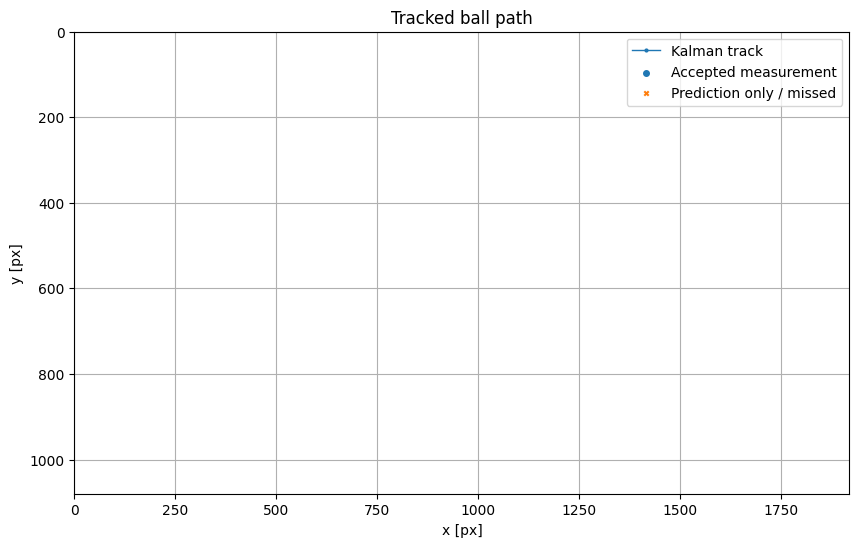

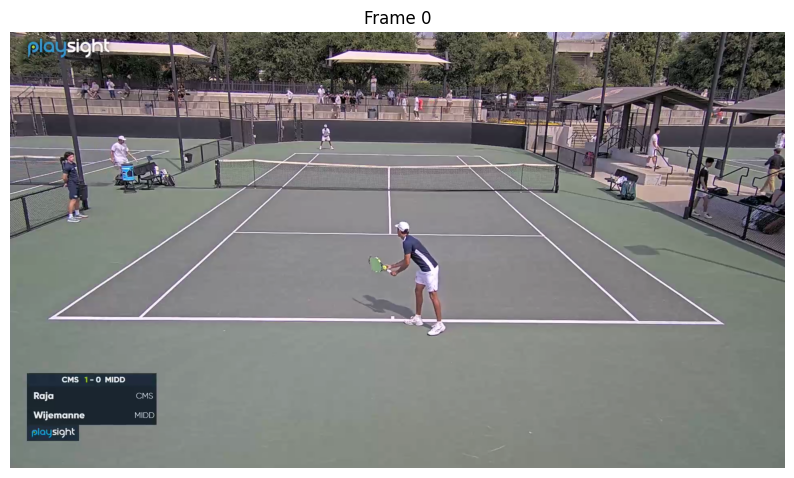

In [33]:
# # After running the tracker:
plot_track_history(history, cfg.frame_width, cfg.frame_height)
show_debug_frame(video_path, history, frame_idx=int(history.iloc[0]["frame_idx"]), resize=resize)

# Save the annotated video and CSV:
# video_out, csv_out = save_tracking_outputs(
#     video_path=video_path,
#     history=history,
#     output_video_path="kalman_ball_tracking_overlay.mp4",
#     output_csv_path="kalman_ball_tracking_history.csv",
#     resize=resize,
#     trail_length=25,
# )
# video_out, csv_out


## 13. Tuning notes

Important parameters to tune first:

- `measurement_std_px`: larger means candidates farther from the predicted position can still be accepted.
- `gate_mahalanobis2`: larger means a looser hard gate.
- `min_detection_score`: larger means more frames will be treated as missed detections.
- `max_missed_frames`: how long the tracker can coast without a good candidate.
- `maneuver_pos_std` and `maneuver_vel_std`: larger means the predicted uncertainty expands faster after misses, helping with racket hits/bounces but increasing false associations.
- `center_bias_weight`: keep this small. It is only a prior, not a rule.

For your use case, it is normal and desirable that many frames become `missed_*`. During dead time between points, the tracker should usually fail to confirm a stable track rather than hallucinate a ball.

A good workflow is:

1. Make candidate extraction permissive enough that the true ball is often present somewhere in the top candidates.
2. Start with a loose Kalman gate and low `min_detection_score`.
3. Inspect false tracks.
4. Increase `min_detection_score`, reduce `gate_mahalanobis2`, or increase `max_missed_frames` depending on whether you are getting false positives, lost tracks, or fragmented tracks.